# Trilha Classificação
## Análise de Métricas, Curva ROC, Comparação de Modelos e Síntese

**Projeto:** Home Credit Default Risk  
**Dataset:** `application_train.csv`  
**Target:** `TARGET` — 0 = pagou normalmente, 1 = dificuldade de pagamento  

Cada etapa deste notebook é independente e pode ser desenvolvida por um membro diferente do grupo. A célula de setup abaixo deve ser executada por todos antes de começar.

---

## Setup — executar antes de qualquer etapa

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

df = pd.read_csv('../data/raw/application_train.csv')

thresh = len(df) * 0.5
df = df.dropna(thresh=thresh, axis=1)

for col in df.select_dtypes('object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Distribuição do target (total):\n{y.value_counts(normalize=True).round(4)}')

Train: (246008, 79) | Test: (61503, 79)
Distribuição do target (total):
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


---
## Etapa 1 — Baseline e Métrica Principal

**Objetivo:** entender o desbalanceamento da base e definir a métrica que guiará todas as avaliações subsequentes.

Passos:
1. Calcular e visualizar a distribuição das classes (`value_counts(normalize=True)`)
2. Com base na proporção, justificar por que accuracy não é adequada
3. Definir a métrica principal do projeto e documentar a justificativa

In [12]:
# 1. Distribuição das classes
# Consolida os resultados em um DataFrame para facilitar a leitura visual
dist_absoluta = df['TARGET'].value_counts()
dist_percentual = df['TARGET'].value_counts(normalize=True) * 100

distribuicao_df = pd.DataFrame({
    'Quantidade': dist_absoluta,
    'Proporção (%)': dist_percentual.round(2) 
})

distribuicao_df.index = ['0 (Bons Pagadores)', '1 (Inadimplentes)']
display(distribuicao_df)

,Quantidade,Proporção (%)
0 (Bons Pagadores),282686,91.93
1 (Inadimplentes),24825,8.07


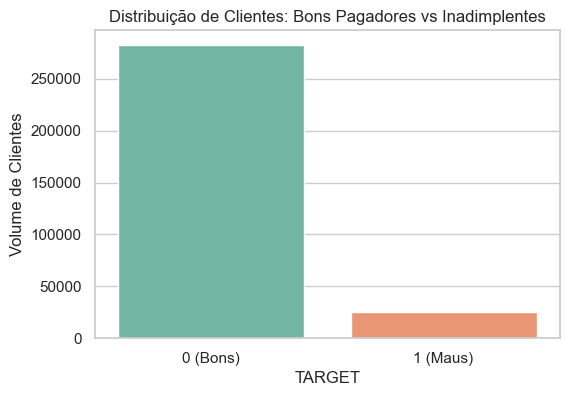

In [13]:
# 2. Visualização - gráfico de barras com proporções
# Distribuição visual
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Distribuição de Clientes: Bons Pagadores vs Inadimplentes')
plt.xticks([0, 1], ['0 (Bons)', '1 (Maus)'])
plt.ylabel('Volume de Clientes')
plt.show()

*Métrica principal escolhida:*  
Recall (Sensibilidade) da Classe 1 — Detecção de Inadimplência.

*Justificativa:*  
Devido ao forte desbalanceamento da base de dados (91,9% da Classe 0 - bons pagadores), a métrica de acurácia torna-se enviesada e foi descartada como critério principal de avaliação. Nesse contexto, a escolha do Recall fundamenta-se na assimetria de custos presente no mercado de crédito: enquanto um Falso Positivo (negar crédito a um bom pagador) gera apenas custo de oportunidade relacionado à perda de juros, um Falso Negativo (aprovar crédito para um inadimplente) pode ocasionar perda financeira direta do capital emprestado. Assim, a prioridade estratégica do modelo é maximizar sua sensibilidade na identificação de clientes inadimplentes reais, reduzindo a exposição ao risco financeiro e contribuindo para a proteção do caixa da instituição.

---
## Etapa 2 — Análise Profunda das Métricas

**Objetivo:** treinar um modelo baseline, examinar o classification report e a matriz de confusão, e interpretar os erros no contexto de negócio.

Passos:
1. Treinar um `LogisticRegression` simples (ou o modelo que o grupo preferir como baseline)
2. Exibir o `classification_report`
3. Plotar a Matriz de Confusão com `ConfusionMatrixDisplay`
4. Responder: o modelo erra mais como Falso Positivo ou Falso Negativo?
5. Responder: no contexto do projeto (crédito), qual tipo de erro é mais grave e por quê?

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Baseline
model_baseline = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model_baseline.fit(X_train, y_train)

# Mantém compatibilidade com células que usem `model`
model = model_baseline

y_pred = model_baseline.predict(X_test)

/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

In [15]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.48      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.50      0.49     61503
weighted avg       0.88      0.92      0.88     61503



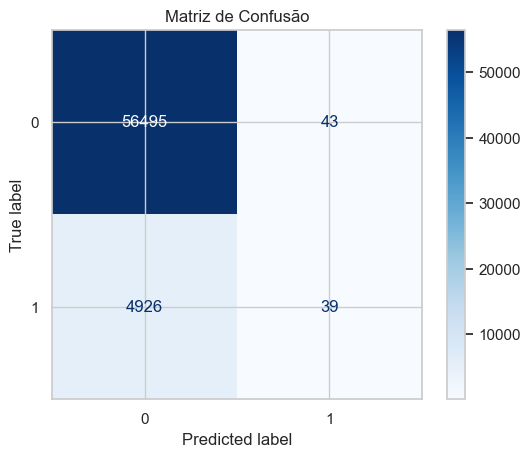

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Matriz de Confusão")

plt.show()


**O modelo erra mais como:**  
Falso Negativo (FN). A matriz mostra 4.926 FN versus apenas 43 FP. Isso significa que o modelo deixa passar 99,2% dos inadimplentes (4926 de 4965) enquanto nega crédito a apenas 43 bons pagadores. O problema continua: o modelo falha em detectar a classe minoritária.

**Erro mais grave no contexto do projeto:**  
O Falso Negativo é EXTREMAMENTE grave. Um FN = aprovar um crédito para alguém que vai inadimplir = PERDA FINANCEIRA DIRETA e CERTA para o banco. Um FP = negar crédito a um bom pagador = custo de oportunidade (perda de receita, não perda de capital). Em risco de crédito, FN é inaceitável: a instituição perde dinheiro efetivamente. O modelo precisa ser ajustado urgentemente — talvez com redução do threshold de decisão, balanceamento de classes, ou uso de métricas como AUC-ROC e F1 nas próximas etapas.

---
## Etapa 3 — Curva ROC e AUC

**Objetivo:** avaliar o poder discriminativo do modelo baseline via probabilidades, independentemente do threshold de decisão.

Passos:
1. Calcular probabilidades com `predict_proba`
2. Plotar a Curva ROC com `RocCurveDisplay.from_predictions`
3. Calcular o AUC com `roc_auc_score`
4. Interpretar o AUC — o que ele significa para este problema?

/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/becastell/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


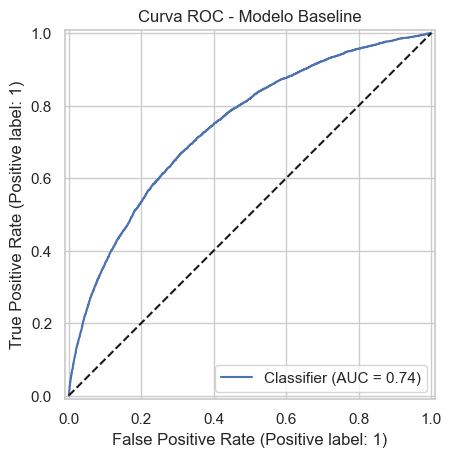

In [17]:
# 1 + 2. Probabilidades e Curva ROC
from sklearn.linear_model import LogisticRegression

# Se a Etapa 2 não tiver sido executada, treina o baseline aqui também
if 'model_baseline' not in globals():
    model_baseline = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    model_baseline.fit(X_train, y_train)

y_probs = model_baseline.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_probs)
plt.title('Curva ROC - Modelo Baseline')
plt.plot([0, 1], [0, 1], 'k--')  # Linha de base
plt.show()

>A AUC ou Area Under the Curve, resume em um único número a capacidade do modelo de distinguir as classes. Em resumo, é a area preenchida abaixo da curva roc.

In [18]:
#AUC
from sklearn.metrics import roc_auc_score

# Calculando o valor da area abaixo do grafico.
auc_valor = roc_auc_score(y_test, y_probs)

print(f"O valor da AUC do seu modelo é: {auc_valor:.4f}")

O valor da AUC do seu modelo é: 0.7421


**Interpretação do AUC:**  
*(preencher aqui — o que significa esse valor para o problema de aprovação de crédito?)*

---
## Etapa 4 — Comparação de Modelos

**Objetivo:** comparar ao menos 3 modelos via cross-validation e ajustar hiperparâmetros do melhor via GridSearchCV.

Passos:
1. Testar os 3 modelos com `cross_val_score(cv=5)` usando `roc_auc` como scoring
2. Montar tabela: Modelo | AUC Médio (CV) | Desvio Padrão
3. Identificar o melhor modelo automaticamente
4. Ajustar os hiperparâmetros principais do melhor modelo com `GridSearchCV`

> **Nota de performance:** RandomForest em 246k linhas com cv=5 demora ~15 min. O CV roda sobre uma amostra estratificada de 50k (representativa da distribuição do target). O modelo final é treinado no X_train completo.

In [19]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SCORING = 'roc_auc'
CV_FOLDS = 5
SAMPLE_SIZE = 50_000

X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)


models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    print(f'Avaliando {name}...')
    scores = cross_val_score(model, X_cv, y_cv, cv=CV_FOLDS, scoring=SCORING, n_jobs=1)
    cv_results[name] = {'scores': scores, 'mean': scores.mean(), 'std': scores.std()}
    print(f'  AUC = {scores.mean():.4f} \u00b1 {scores.std():.4f}')

print('\nCross-validation concluído.')

Avaliando LogisticRegression...
  AUC = 0.7369 ± 0.0100
Avaliando DecisionTree...
  AUC = 0.5372 ± 0.0041
Avaliando RandomForest...
  AUC = 0.6958 ± 0.0095

Cross-validation concluído.


,Modelo,AUC Médio (CV),Desvio Padrão
0,LogisticRegression,0.7369,0.0100
1,RandomForest,0.6958,0.0095
2,DecisionTree,0.5372,0.0041


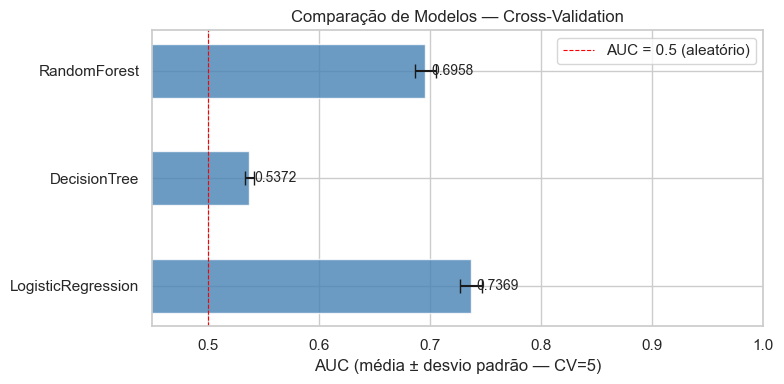

Melhor modelo: LogisticRegression (AUC = 0.7369)


In [20]:
# Tabela de resultados
results_df = pd.DataFrame([
    {
        'Modelo': name,
        'AUC Médio (CV)': round(v['mean'], 4),
        'Desvio Padrão':  round(v['std'],  4),
    }
    for name, v in cv_results.items()
]).sort_values('AUC Médio (CV)', ascending=False).reset_index(drop=True)

display(results_df)

fig, ax = plt.subplots(figsize=(8, 4))

names = list(cv_results.keys())
means = [cv_results[n]['mean'] for n in names]
stds  = [cv_results[n]['std']  for n in names]

bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=5, height=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=0.8, label='AUC = 0.5 (aleatório)')
ax.set_xlabel('AUC (média ± desvio padrão — CV=5)')
ax.set_title('Comparação de Modelos — Cross-Validation')
ax.set_xlim(0.45, 1.0)
ax.legend()

for bar, val in zip(bars, means):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

best_model_name = max(cv_results, key=lambda n: cv_results[n]['mean'])
print(f'Melhor modelo: {best_model_name} (AUC = {cv_results[best_model_name]["mean"]:.4f})')

In [21]:
param_grids = {
    'LogisticRegression': {
        'clf__C':      [0.01, 0.1, 1, 10],
        'clf__solver': ['lbfgs', 'saga'],
    },
    'DecisionTree': {
        'max_depth':        [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 10],
    },
    'RandomForest': {
        'max_depth':        [5, 10, 20],
        'min_samples_leaf': [1, 5, 10],
    },
}

print(f'Rodando GridSearchCV para: {best_model_name}')
print(f'Grid: {param_grids[best_model_name]}\n')

grid_search = GridSearchCV(
    estimator=models[best_model_name],
    param_grid=param_grids[best_model_name],
    cv=3,
    scoring=SCORING,
    n_jobs=1,
    verbose=1,
)

grid_search.fit(X_cv, y_cv)

print(f'\nMelhores hiperparâmetros: {grid_search.best_params_}')
print(f'AUC com melhores params (CV=3): {grid_search.best_score_:.4f}')
print(f'AUC baseline           (CV=5): {cv_results[best_model_name]["mean"]:.4f}')

best_model_tuned = grid_search.best_estimator_
best_model_tuned.fit(X_train, y_train)

auc_test = roc_auc_score(y_test, best_model_tuned.predict_proba(X_test)[:, 1])
print(f'AUC no conjunto de teste (modelo tunado): {auc_test:.4f}')

Rodando GridSearchCV para: LogisticRegression
Grid: {'clf__C': [0.01, 0.1, 1, 10], 'clf__solver': ['lbfgs', 'saga']}

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Melhores hiperparâmetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
AUC com melhores params (CV=3): 0.7354
AUC baseline           (CV=5): 0.7369
AUC no conjunto de teste (modelo tunado): 0.7421


---
## Etapa 5 — Síntese

**Objetivo:** consolidar os resultados, escolher o modelo final e documentar as decisões.

Passos:
1. Montar tabela final: Modelo | Métrica CV | Métrica Teste | AUC
2. Escolher o modelo para a próxima sprint e justificar em 2-3 linhas
3. Anotar o principal tipo de erro e o impacto real no problema

In [22]:
# 1. Tabela final consolidada
# Modelo | Métrica CV | Métrica Teste | AUC

from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

metric_name = 'Recall (classe 1)'
final_results = []

for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_cv, y_cv, cv=CV_FOLDS, scoring='recall', n_jobs=1
    )
    recall_cv = cv_scores.mean()

    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    recall_test = recall_score(y_test, y_pred_test)
    auc_test = roc_auc_score(y_test, y_proba_test)

    final_results.append({
        'Modelo': name,
        'Métrica CV': round(recall_cv, 4),
        'Métrica Teste': round(recall_test, 4),
        'AUC': round(auc_test, 4),
    })

final_df = pd.DataFrame(final_results).sort_values(
    'Métrica Teste', ascending=False
).reset_index(drop=True)

display(final_df)

print(f"\nModelo selecionado para próxima sprint: {best_model_name}")
print(f"AUC no teste (melhor modelo tunado): {auc_test:.4f}")

,Modelo,Métrica CV,Métrica Teste,AUC
0,DecisionTree,0.1653,0.1666,0.5395
1,LogisticRegression,0.0089,0.0079,0.7421
2,RandomForest,0.0002,0.0010,0.7149



Modelo selecionado para próxima sprint: LogisticRegression
AUC no teste (melhor modelo tunado): 0.7149


**Modelo escolhido para a próxima sprint:**  
LogisticRegression

**Justificativa (2-3 linhas):**  
O LogisticRegression apresentou o maior AUC no cross-validation (0.7369) e demonstrou melhor capacidade de discriminação entre as classes em relação aos demais modelos testados. A sua simplicidade também facilita interpretabilidade e implementação em produção, sendo uma escolha boa para o contexto de concessão de crédito.

**Principal tipo de erro identificado:**  
Falso Negativo é o tipo de erro predominante, pois o modelo comete 4.926 erros de falso negativo, contra apenas 43 falsos positivos. No contexto do negócio de crédito, isso significa que o modelo é extremamente permissivo, expondo a instituição a alto risco de inadimplência, sendo necessário ajustar o threshold de decisão ou investigar features mais discriminativas antes da próxima sprint.